# Guessing

In [ ]:
def guess_month():
    print("Let's play a month guessing game! Think of a month between 1 and 12.\n")

    lower_bound = 1
    upper_bound = 12
    guesses_taken = 0
    correct_guess = False

    while not correct_guess:
        guesses_taken += 1
        current_guess = (lower_bound + upper_bound) // 2

        print(f"Computer's guess: {current_guess}")
        # 'A' (Smaller) and 'D' (Larger)
        feedback = input("Is your month Smaller (A), Larger (D), or Correct (S)? ").upper()

        if feedback == 'A':  # Smaller
            upper_bound = current_guess - 1
        elif feedback == 'D':  # Larger
            lower_bound = current_guess + 1
        elif feedback == 'S':
            correct_guess = True
            print(f"Great! Your birthday month is {current_guess}.")
            return current_guess, guesses_taken
        else:
            print("Invalid input. Please enter 'A', 'D', or 'S'.")
            guesses_taken -= 1  # invalid input not counted
            continue

        # for consecutive numbers guessses, directly get the answer
        if lower_bound == upper_bound:
            correct_guess = True
            print(f"Great! Your month was {lower_bound}.")
            return lower_bound, guesses_taken

        # Optional: Check for impossible scenarios (e.g., user cheats or makes inconsistent choices)
        if lower_bound > upper_bound:
            print("It seems there was an inconsistency in your feedback. Let's restart or check your month.")
            return None, guesses_taken # Return None for month to indicate inconsistency

def guess_date(max_day):
    print(f"\nLet's play a date guessing game! Think of a date between 1 and {max_day}.\n")

    lower_bound = 1
    upper_bound = max_day
    guesses_taken = 0
    correct_guess = False

    while not correct_guess:
        guesses_taken += 1
        current_guess = (lower_bound + upper_bound) // 2

        print(f"Computer's guess: {current_guess}")
        # 'A' (Smaller) and 'D' (Larger)
        feedback = input("Is your date Smaller (A), Larger (D), or Correct (S)? ").upper()

        if feedback == 'A':  # User says Smaller
            upper_bound = current_guess - 1
        elif feedback == 'D':  # User says Larger
            lower_bound = current_guess + 1
        elif feedback == 'S':
            correct_guess = True
            print(f"Great! Your date was {current_guess}.")
            return current_guess, guesses_taken
        else:
            print("Invalid input. Please enter 'A', 'D', or 'S'.")
            guesses_taken -= 1  # Don't count invalid input as a guess
            continue  # Ask for feedback again without new guess

        # Optimization: If bounds converge to a single number after feedback, it's the answer.
        if lower_bound == upper_bound:
            correct_guess = True
            print(f"Great! Your date was {lower_bound}.")
            return lower_bound, guesses_taken

        if lower_bound > upper_bound:
            print("It seems there was an inconsistency in your feedback. Let's restart or check your date.")
            return None, guesses_taken

def get_birthday_group(month, day):
    # Group A: (3/21-4/19) or (7/23-8/22)
    if (month == 3 and day >= 21) or \
       (month == 4 and day <= 19) or \
       (month == 7 and day >= 23) or \
       (month == 8 and day <= 22):
        return "Group A"
    # Group B: (11/22-12/21) or (4/20-5/20)
    elif (month == 11 and day >= 22) or \
         (month == 12 and day <= 21) or \
         (month == 4 and day >= 20) or \
         (month == 5 and day <= 20):
        return "Group B"
    # Group C: (8/23-9/22) or (12/22-1/19)
    elif (month == 8 and day >= 23) or \
         (month == 9 and day <= 22) or \
         (month == 12 and day >= 22) or \
         (month == 1 and day <= 19):
        return "Group C"
    # Group D: (5/21-6/20) or (9/23-10/22)
    elif (month == 5 and day >= 21) or \
         (month == 6 and day <= 20) or \
         (month == 9 and day >= 23) or \
         (month == 10 and day <= 22):
        return "Group D"
    # Group E: (1/20-2/18) or (6/21-7/22)
    elif (month == 1 and day >= 20) or \
         (month == 2 and day <= 18) or \
         (month == 6 and day >= 21) or \
         (month == 7 and day <= 22):
        return "Group E"
    # Group F: (10/23-11/21) or (2/19-3/20)
    elif (month == 10 and day >= 23) or \
         (month == 11 and day <= 21) or \
         (month == 2 and day >= 19) or \
         (month == 3 and day <= 20):
        return "Group F"
    else:
        return "Unknown Group"

if __name__ == '__main__':
    # 3. Call the guess_month() function
    guessed_month, month_guesses = guess_month()

    if guessed_month is None:
        print("Month guessing failed due to inconsistent feedback. Exiting game.")
    else:
        # 4. Determine max_day based on the returned month (now including Feb 29 for consistency)
        days_in_month = {
            1: 31, 2: 29, 3: 31, 4: 30, 5: 31, 6: 30,
            7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
        }
        max_day_for_month = days_in_month.get(guessed_month, 31) # Default to 31 if month is somehow invalid

        # 5. Call the guess_date() function with the determined maximum number of days
        guessed_date, date_guesses = guess_date(max_day_for_month)

        if guessed_date is None:
            print("Date guessing failed due to inconsistent feedback. Exiting game.")
        else:
            # 6. Print the final guessed birth month, birth date, and total guesses
            total_guesses = month_guesses + date_guesses
            print(f"\nI guessed your birthday! It's Month {guessed_month}, Day {guessed_date}.")
            print(f"Total guesses taken: {total_guesses} (Month: {month_guesses}, Date: {date_guesses})")

            # 7. Determine and print the birthday group
            birthday_group = get_birthday_group(guessed_month, guessed_date)
            print(f"Your birthday falls into: {birthday_group}")

Let's play a month guessing game! Think of a month between 1 and 12.

Computer's guess: 6


In [ ]:
def simulate_guessing(target_value, lower_bound, upper_bound):
    guesses_taken = 0

    while True:
        guesses_taken += 1
        current_guess = (lower_bound + upper_bound) // 2

        if current_guess == target_value:
            return guesses_taken
        elif current_guess < target_value:
            # Target is larger, so adjust lower bound
            lower_bound = current_guess + 1
        else: # current_guess > target_value
            # Target is smaller, so adjust upper bound
            upper_bound = current_guess - 1

        # Optimization: If bounds converge to a single number after feedback, it's the answer.
        if lower_bound == upper_bound:
            # At this point, lower_bound (or upper_bound) must be the target_value
            return guesses_taken

        # This check is primarily for robustness, though for valid inputs, target_value will always be found
        if lower_bound > upper_bound:
            # This case implies an invalid target_value for the given range or an error in logic
            # For this simulation, we assume target_value is always within the initial bounds
            return -1 # Indicate failure or out-of-bounds

In [ ]:
all_total_guesses = []

days_in_month = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

# Loop through each month
for month in range(1, 13):
    max_day_for_current_month = days_in_month.get(month, 31) # Default to 31 if month is somehow invalid

    # Loop through each day in the current month
    for day in range(1, max_day_for_current_month + 1):
        # Simulate month guessing
        month_guesses = simulate_guessing(month, 1, 12)

        # Simulate date guessing
        date_guesses = simulate_guessing(day, 1, max_day_for_current_month)

        # Calculate total guesses for this specific day
        total_guesses_for_day = month_guesses + date_guesses

        # Append to the list
        all_total_guesses.append(total_guesses_for_day)

# Calculate statistics
total_days_processed = len(all_total_guesses)
sum_of_all_guesses = sum(all_total_guesses)
average_guesses = sum_of_all_guesses / total_days_processed

# Print results
print(f"\n--- Automation Test Results ---")
print(f"Total days processed (excluding February 29th): {total_days_processed}")
print(f"Total sum of all guesses: {sum_of_all_guesses}")
print(f"Average number of guesses needed per birthday: {average_guesses:.2f}")


--- Automation Test Results ---
Total days processed (excluding February 29th): 365
Total sum of all guesses: 2302
Average number of guesses needed per birthday: 6.31


# Task
Update the `days_in_month` dictionary to account for 29 days in February for a leap year, then re-run the automation test to simulate guessing for all 366 possible birthdays. Collect the total guesses for each birthday and finally, calculate and display the minimum, maximum, and average number of guesses across all 366 simulated birthdays.

In [ ]:
all_total_guesses = []

days_in_month = {
    1: 31, 2: 29, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

# Loop through each month
for month in range(1, 13):
    max_day_for_current_month = days_in_month.get(month, 31) # Default to 31 if month is somehow invalid

    # Loop through each day in the current month
    for day in range(1, max_day_for_current_month + 1):
        # Simulate month guessing
        month_guesses = simulate_guessing(month, 1, 12)

        # Simulate date guessing
        date_guesses = simulate_guessing(day, 1, max_day_for_current_month)

        # Calculate total guesses for this specific day
        total_guesses_for_day = month_guesses + date_guesses

        # Append to the list
        all_total_guesses.append(total_guesses_for_day)

# Calculate statistics
total_days_processed = len(all_total_guesses)
sum_of_all_guesses = sum(all_total_guesses)
average_guesses = sum_of_all_guesses / total_days_processed
min_guesses = min(all_total_guesses)
max_guesses = max(all_total_guesses)

# Print results
print(f"\n--- Automation Test Results ---")
print(f"Total days processed (including February 29th): {total_days_processed}")
print(f"Total sum of all guesses: {sum_of_all_guesses}")
print(f"Average number of guesses needed per birthday: {average_guesses:.2f}")
print(f"Minimum guesses needed for any birthday: {min_guesses}")
print(f"Maximum guesses needed for any birthday: {max_guesses}")


--- Automation Test Results ---
Total days processed (including February 29th): 366
Total sum of all guesses: 2309
Average number of guesses needed per birthday: 6.31
Minimum guesses needed for any birthday: 2
Maximum guesses needed for any birthday: 7


In [ ]:
all_total_guesses = []

days_in_month = {
    1: 31, 2: 29, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

# Loop through each month
for month in range(1, 13):
    max_day_for_current_month = days_in_month.get(month, 31) # Default to 31 if month is somehow invalid

    # Loop through each day in the current month
    for day in range(1, max_day_for_current_month + 1):
        # Simulate month guessing
        month_guesses = simulate_guessing(month, 1, 12);

        # Simulate date guessing
        date_guesses = simulate_guessing(day, 1, max_day_for_current_month)

        # Calculate total guesses for this specific day
        total_guesses_for_day = month_guesses + date_guesses

        # Append to the list
        all_total_guesses.append(total_guesses_for_day)

        # Print individual guessing times
        print(f"Month: {month}, Day: {day}, Total Guesses: {total_guesses_for_day}")

# Calculate statistics
total_days_processed = len(all_total_guesses)
sum_of_all_guesses = sum(all_total_guesses)
average_guesses = sum_of_all_guesses / total_days_processed
min_guesses = min(all_total_guesses)
max_guesses = max(all_total_guesses)

# Print results
print(f"\n--- Automation Test Results ---")
print(f"Total days processed (including February 29th): {total_days_processed}")
print(f"Total sum of all guesses: {sum_of_all_guesses}")
print(f"Average number of guesses needed per birthday: {average_guesses:.2f}")
print(f"Minimum guesses needed for any birthday: {min_guesses}")
print(f"Maximum guesses needed for any birthday: {max_guesses}")

Month: 1, Day: 1, Total Guesses: 7
Month: 1, Day: 2, Total Guesses: 7
Month: 1, Day: 3, Total Guesses: 7
Month: 1, Day: 4, Total Guesses: 6
Month: 1, Day: 5, Total Guesses: 7
Month: 1, Day: 6, Total Guesses: 7
Month: 1, Day: 7, Total Guesses: 7
Month: 1, Day: 8, Total Guesses: 5
Month: 1, Day: 9, Total Guesses: 7
Month: 1, Day: 10, Total Guesses: 7
Month: 1, Day: 11, Total Guesses: 7
Month: 1, Day: 12, Total Guesses: 6
Month: 1, Day: 13, Total Guesses: 7
Month: 1, Day: 14, Total Guesses: 7
Month: 1, Day: 15, Total Guesses: 7
Month: 1, Day: 16, Total Guesses: 4
Month: 1, Day: 17, Total Guesses: 7
Month: 1, Day: 18, Total Guesses: 7
Month: 1, Day: 19, Total Guesses: 7
Month: 1, Day: 20, Total Guesses: 6
Month: 1, Day: 21, Total Guesses: 7
Month: 1, Day: 22, Total Guesses: 7
Month: 1, Day: 23, Total Guesses: 7
Month: 1, Day: 24, Total Guesses: 5
Month: 1, Day: 25, Total Guesses: 7
Month: 1, Day: 26, Total Guesses: 7
Month: 1, Day: 27, Total Guesses: 7
Month: 1, Day: 28, Total Guesses: 6
M

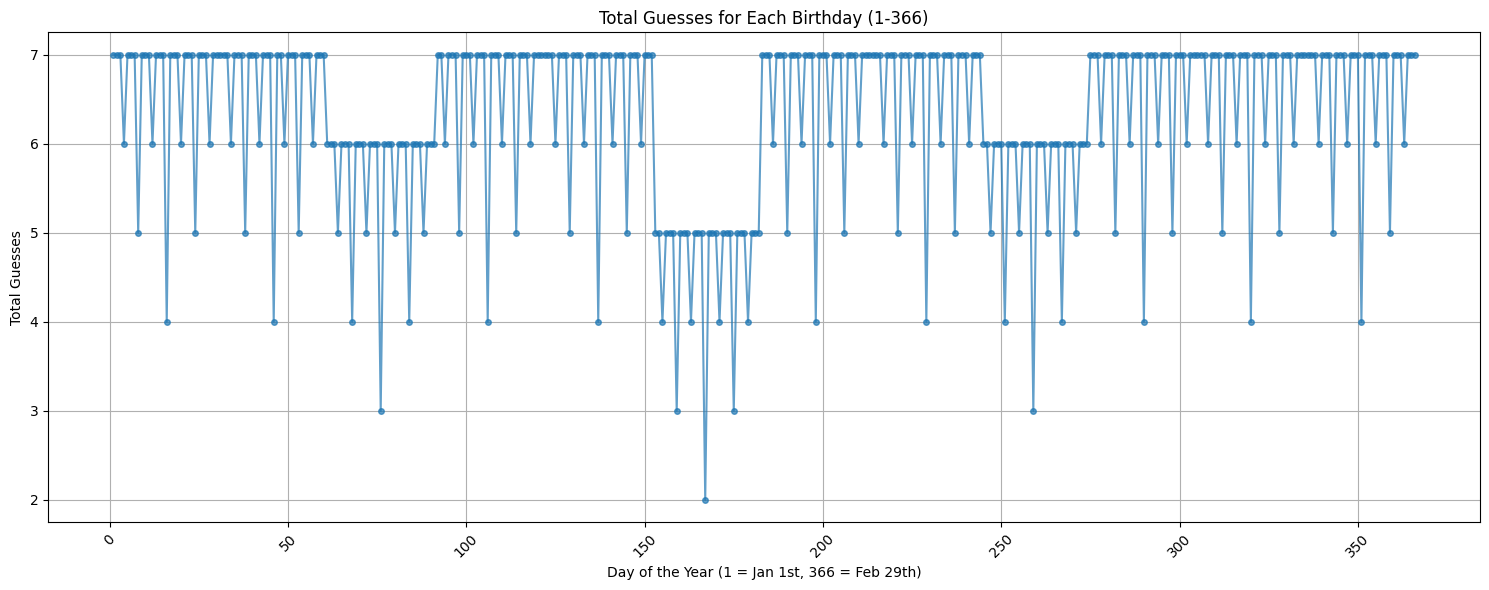

In [ ]:
import matplotlib.pyplot as plt

# Create a list of day numbers from 1 to 366
day_numbers = list(range(1, len(all_total_guesses) + 1))

plt.figure(figsize=(15, 6))
plt.plot(day_numbers, all_total_guesses, marker='o', linestyle='-', markersize=4, alpha=0.7)
plt.title('Total Guesses for Each Birthday (1-366)')
plt.xlabel('Day of the Year (1 = Jan 1st, 366 = Feb 29th)')
plt.ylabel('Total Guesses')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()